<a href="https://colab.research.google.com/github/veektortee/AI-Powered-Resume-Classifier/blob/main/AI_Powered_Resume_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Download CUDA 11.8 Toolkit
!wget https://developer.download.nvidia.com/compute/cuda/11.8.0/local_installers/cuda_11.8.0_520.61.05_linux.run

--2025-05-21 10:55:46--  https://developer.download.nvidia.com/compute/cuda/11.8.0/local_installers/cuda_11.8.0_520.61.05_linux.run
Resolving developer.download.nvidia.com (developer.download.nvidia.com)... 23.43.51.15, 23.43.51.10
Connecting to developer.download.nvidia.com (developer.download.nvidia.com)|23.43.51.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4336730777 (4.0G) [application/octet-stream]
Saving to: ‘cuda_11.8.0_520.61.05_linux.run’

cuda_11.8.0_520.61. 100%[===================>]   4.04G   322MB/s    in 12s     

2025-05-21 10:55:59 (334 MB/s) - ‘cuda_11.8.0_520.61.05_linux.run’ saved [4336730777/4336730777]



In [3]:
# Install CUDA
!sudo sh cuda_11.8.0_520.61.05_linux.run --silent --toolkit --override

In [4]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:33:58_PDT_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0


In [5]:
# Copy .xz file to Colab
!cp /content/drive/MyDrive/CUDA/cudnn-linux-x86_64-8.6.0.163_cuda11-archive.tar.xz .

# Extract file
!tar -xJvf cudnn-linux-x86_64-8.6.0.163_cuda11-archive.tar.xz

# Copy the cuDNN Files to CUDA Paths
!sudo cp cudnn-linux-x86_64-8.6.0.163_cuda11-archive/include/* /usr/local/cuda/include/
!sudo cp cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/* /usr/local/cuda/lib64/

# Set Permissions
!sudo chmod a+r /usr/local/cuda/include/cudnn*.h /usr/local/cuda/lib64/libcudnn*

cudnn-linux-x86_64-8.6.0.163_cuda11-archive/
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_adv_infer_static.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_adv_infer_static_v8.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_adv_train_static.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_adv_train_static_v8.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_cnn_infer_static.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_cnn_infer_static_v8.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_cnn_train_static.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_cnn_train_static_v8.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_ops_infer_static.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_ops_infer_static_v8.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudnn_ops_train_static.a
cudnn-linux-x86_64-8.6.0.163_cuda11-archive/lib/libcudn

In [6]:
import os

# Update Environment Variables
os.environ['LD_LIBRARY_PATH'] += ':/usr/local/cuda/lib64'
!ldconfig

/sbin/ldconfig.real: /usr/local/cuda/targets/x86_64-linux/lib/libcudnn_cnn_train.so.8 is not a symbolic link

/sbin/ldconfig.real: /usr/local/cuda/targets/x86_64-linux/lib/libcudnn.so.8 is not a symbolic link

/sbin/ldconfig.real: /usr/local/cuda/targets/x86_64-linux/lib/libcudnn_ops_infer.so.8 is not a symbolic link

/sbin/ldconfig.real: /usr/local/cuda/targets/x86_64-linux/lib/libcudnn_cnn_infer.so.8 is not a symbolic link

/sbin/ldconfig.real: /usr/local/cuda/targets/x86_64-linux/lib/libcudnn_adv_train.so.8 is not a symbolic link

/sbin/ldconfig.real: /usr/local/cuda/targets/x86_64-linux/lib/libcudnn_adv_infer.so.8 is not a symbolic link

/sbin/ldconfig.real: /usr/local/cuda/targets/x86_64-linux/lib/libcudnn_ops_train.so.8 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconf

In [7]:
# Verify Installation
!ls -l /usr/local/cuda/lib64/ | grep libcudnn

-rwxr-xr-x 1 root root 130410576 May 21 10:59 libcudnn_adv_infer.so
-rwxr-xr-x 1 root root 130410576 May 21 10:59 libcudnn_adv_infer.so.8
-rwxr-xr-x 1 root root 130410576 May 21 10:59 libcudnn_adv_infer.so.8.6.0
-rw-r--r-- 1 root root 133003914 May 21 10:59 libcudnn_adv_infer_static.a
-rw-r--r-- 1 root root 133003914 May 21 10:59 libcudnn_adv_infer_static_v8.a
-rwxr-xr-x 1 root root 112346064 May 21 10:59 libcudnn_adv_train.so
-rwxr-xr-x 1 root root 112346064 May 21 10:59 libcudnn_adv_train.so.8
-rwxr-xr-x 1 root root 112346064 May 21 10:59 libcudnn_adv_train.so.8.6.0
-rw-r--r-- 1 root root 114815396 May 21 10:59 libcudnn_adv_train_static.a
-rw-r--r-- 1 root root 114815396 May 21 10:59 libcudnn_adv_train_static_v8.a
-rwxr-xr-x 1 root root 620049392 May 21 11:00 libcudnn_cnn_infer.so
-rwxr-xr-x 1 root root 620049392 May 21 11:00 libcudnn_cnn_infer.so.8
-rwxr-xr-x 1 root root 620049392 May 21 11:00 libcudnn_cnn_infer.so.8.6.0
-rw-r--r-- 1 root root 789475930 May 21 11:00 libcudnn_cnn_inf

In [8]:
# Check cuDNN Version
!cat /usr/local/cuda/include/cudnn_version.h | grep CUDNN_MAJOR -A 2

#define CUDNN_MAJOR 8
#define CUDNN_MINOR 6
#define CUDNN_PATCHLEVEL 0
--
#define CUDNN_VERSION (CUDNN_MAJOR * 1000 + CUDNN_MINOR * 100 + CUDNN_PATCHLEVEL)

/* cannot use constexpr here since this is a C-only file */


In [9]:
# Clean install of known working versions
!pip install tensorflow==2.12 keras==2.12 transformers==4.38 numpy tf-keras tqdm nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [1]:
# Import necessary libraries
import tensorflow as tf
from transformers import TFBertModel, BertTokenizer, TFDistilBertModel, DistilBertTokenizer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import random
import nltk
from tqdm import tqdm
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from itertools import chain
from transformers import GPT2LMHeadModel, GPT2Tokenizer

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [3]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

2.12.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


In [4]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:33:58_PDT_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0


**Inspect Data**

In [5]:
# If you uploaded Resume.csv to Colab directly:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Resume.csv")

In [6]:
# Parameters
SEQUENCE_LENGTH = 512
BATCH_SIZE = 16
EPOCHS = 10

In [7]:
# Display basic info
print("Basic Info:")
print(df.info())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None

Data Types:
 ID              int64
Resume_str     object
Resume_html    object
Category       object
dtype: object

First 5 Rows:
          ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_htm

In [8]:
# Count the number of duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


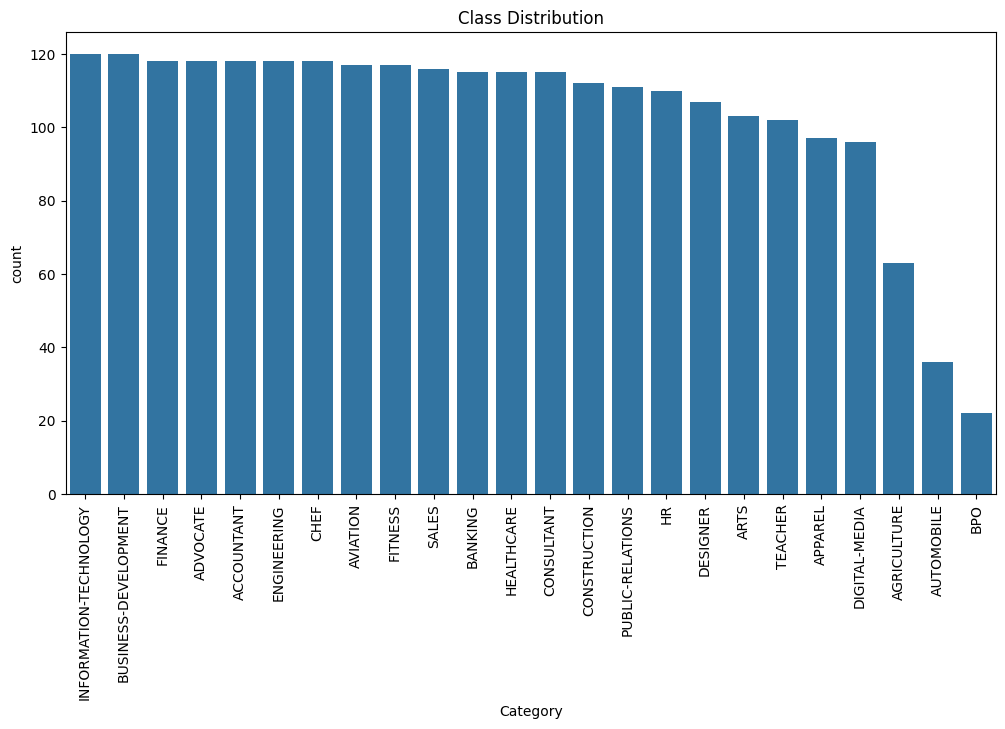

In [9]:
# Class Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

In [10]:
# Class Distribution (Numerical)
class_counts = df['Category'].value_counts()
print("\nClass Distribution:\n", class_counts)


Class Distribution:
 Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [11]:
# Clean data
import re
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_html(text):
    """Remove HTML tags."""
    return re.sub(r'<.*?>', ' ', text)

def remove_digits(text):
    """Remove digits."""
    return re.sub(r'\d+', ' ', text)

def remove_links(text):
    """Remove URLs."""
    return re.sub(r'http\S+|www\S+|https\S+', ' ', text)

def remove_special_characters(text):
    """Remove special characters."""
    return re.sub(r'[^\w\s]', ' ', text)

def remove_non_ascii(text):
    """Remove non-ascii characters."""
    return re.sub(r'[^\x00-\x7F]+', ' ', text)

def remove_email_addresses(text):
    """Remove email addresses."""
    return re.sub(r'\S+@\S+', ' ', text)

def lower(text):
    """Convert to lowercase."""
    return text.lower()

def remove_stopwords(text):
    """Remove stopwords."""
    return " ".join([word for word in text.split() if word not in stop_words])

def remove_extra_spaces(text):
    """Remove extra spaces."""
    return re.sub(r'\s+', ' ', text).strip()

def text_preprocess(data, col):
    """
    Apply all preprocessing functions to the specified column.
    """
    data[col] = data[col].apply(func=clean_html)
    data[col] = data[col].apply(func=remove_digits)
    data[col] = data[col].apply(func=remove_links)
    data[col] = data[col].apply(func=remove_special_characters)
    data[col] = data[col].apply(func=remove_non_ascii)
    data[col] = data[col].apply(func=remove_email_addresses)
    data[col] = data[col].apply(func=lower)
    data[col] = data[col].apply(func=remove_stopwords)
    data[col] = data[col].apply(func=remove_extra_spaces)
    return data

# Apply text preprocessing
df = text_preprocess(df, 'Resume_str')

# Verify cleaning
print(df[['Resume_str']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                          Resume_str
0  hr administrator marketing associate hr admini...
1  hr specialist us hr operations summary versati...
2  hr director summary years experience recruitin...
3  hr specialist summary dedicated driven dynamic...
4  hr manager skill highlights hr skills hr depar...


In [12]:
# Load DistilBert tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize each resume and get its length
df['text_length'] = df['Resume_str'].apply(lambda x: len(tokenizer.tokenize(str(x))))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [13]:
# Remove any row with no text
df = df[df['Resume_str'].str.strip() != ""]
df = df.dropna(subset=['Resume_str'])

In [14]:
# Example of longest and shortest resumes
longest_resume = df.loc[df['text_length'].idxmax()]
shortest_resume = df.loc[df['text_length'].idxmin()]
print("\nLongest Resume:\n", longest_resume['Resume_str'][:300], "...")
print("\nShortest Resume:\n", shortest_resume['Resume_str'][:300], "...")


Longest Resume:
 bartender experience bartender company name city state marketing public relations years maintain proper adequate set bar daily basis responsible maintaining stock preparing storing garnishes juices perishables ensure product quality attend stand ups prior function obtain details order execute event  ...

Shortest Resume:
 construction worker highlights highly motivated dependable ethical honest dedicated hard working experience company name may may construction worker city state performed demolition work taking rooms cleaning getting ready remodeled company name may august assembly line painter city state paint shop  ...


Split raw data

In [55]:
# Encode labels
label_encoder = LabelEncoder()
df['label_enc'] = label_encoder.fit_transform(df['Category'])

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    df['Resume_str'],
    df['label_enc'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_enc']
)


In [56]:
print("\nClass Distribution:\n", df['label_enc'].value_counts())


Class Distribution:
 label_enc
20    120
9     119
16    118
1     118
0     118
15    118
10    118
6     117
17    117
22    116
7     115
18    115
12    115
11    112
21    111
19    110
13    107
4     103
23    102
3      97
14     96
2      63
5      36
8      22
Name: count, dtype: int64


In [50]:
print("\nClass Distribution:\n", df['Category'].value_counts())


Class Distribution:
 Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [47]:
df[df['text_length'] > 512]

,ID,Resume_str,Resume_html,Category,text_length,label_enc
0,16852973,hr administrator marketing associate hr admini...,"<div class=""fontsize fontface vmargins hmargin...",HR,523,19
1,22323967,hr specialist us hr operations summary versati...,"<div class=""fontsize fontface vmargins hmargin...",HR,567,19
2,33176873,hr director summary years experience recruitin...,"<div class=""fontsize fontface vmargins hmargin...",HR,776,19
4,17812897,hr manager skill highlights hr skills hr depar...,"<div class=""fontsize fontface vmargins hmargin...",HR,945,19
5,11592605,hr generalist summary dedicated focused admini...,"<div class=""fontsize fontface vmargins hmargin...",HR,552,19
...,...,...,...,...,...,...
2477,17655479,pest control tech summary seeking position war...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,587,6
2478,12043694,advanced level wheeled vehicle mechanic career...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,859,6
2480,24589765,government relations communications organizati...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,690,6
2482,21190805,program director office manager summary highly...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,580,6


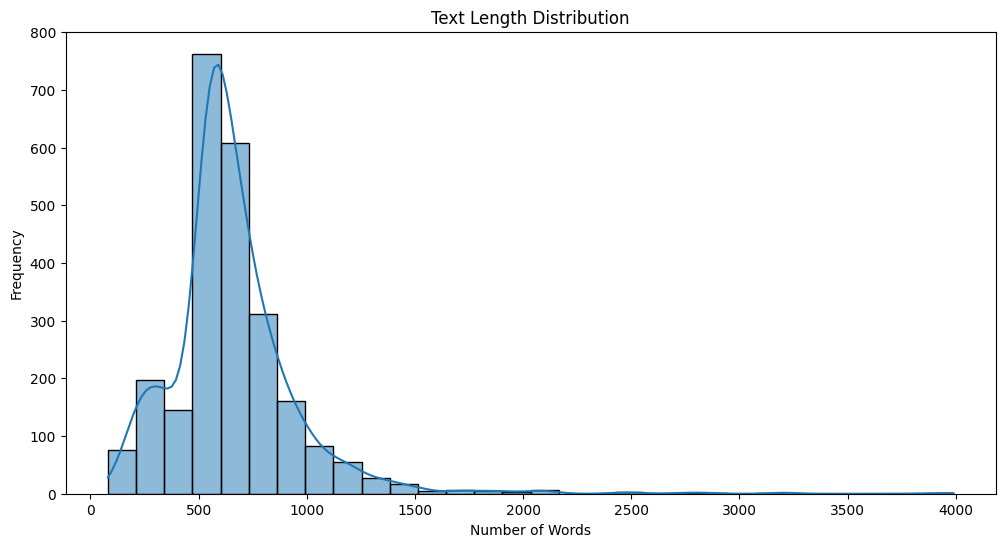

In [26]:
# Text Length Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [27]:
df.loc[df['text_length'].idxmin()] # shortest resume

,1931
ID,22965804
Resume_str,construction worker highlights highly motivate...
Resume_html,"<div class=""fontsize fontface vmargins hmargin..."
Category,CONSTRUCTION
text_length,81
label_enc,11


In [28]:
df.loc[df['text_length'].idxmax()] # longest resume

,2111
ID,11842274
Resume_str,bartender experience bartender company name ci...
Resume_html,"<div class=""fontsize fontface vmargins hmargin..."
Category,PUBLIC-RELATIONS
text_length,3989
label_enc,21


In [57]:
# Tokenize function
def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        max_length=SEQUENCE_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors="tf"
    )

# Tokenize train and test inputs
train_encodings = tokenize_data(X_train)
test_encodings = tokenize_data(X_test)

# Convert to TensorFlow Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": train_encodings["input_ids"],
        "attention_mask": train_encodings["attention_mask"]
    },
    tf.constant(y_train.values, dtype=tf.int32)  # ensure tf-compatible tensor
)).shuffle(1024).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": test_encodings["input_ids"],
        "attention_mask": test_encodings["attention_mask"]
    },
    tf.constant(y_test.values, dtype=tf.int32)
)).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

In [58]:
for inputs, labels in train_dataset.take(1):
    print("Input IDs shape:", inputs["input_ids"].shape)
    print("Attention mask shape:", inputs["attention_mask"].shape)
    print("Labels shape:", labels.shape)

Input IDs shape: (16, 512)
Attention mask shape: (16, 512)
Labels shape: (16,)


In [60]:
# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))

Using Bert Encoder

In [61]:
# Load BERT encoder
bert_encoder = TFDistilBertModel.from_pretrained('distilbert-base-uncased', output_hidden_states=True)

# Build custom model
input_ids = tf.keras.layers.Input(shape=(SEQUENCE_LENGTH,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.layers.Input(shape=(SEQUENCE_LENGTH,), dtype=tf.float32, name="attention_mask")

# BERT outputs
bert_outputs = bert_encoder(input_ids, attention_mask=attention_mask)
hidden_state = bert_outputs.last_hidden_state
cls_output = hidden_state[:, 0, :]

# Custom classification head
x = tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(cls_output)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')(x)

# Full model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBer

In [62]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 512)]        0           []                               
                                                                                                  
 attention_mask (InputLayer)    [(None, 512)]        0           []                               
                                                                                                  
 tf_distil_bert_model_2 (TFDist  TFBaseModelOutput(l  66362880   ['input_ids[0][0]',              
 ilBertModel)                   ast_hidden_state=(N               'attention_mask[0][0]']         
                                one, 512, 768),                                                   
                                 hidden_states=((No                                         

In [63]:
print(model.layers[2].trainable)

True


In [36]:
# Freeze all BERT layers first
model.layers[2].trainable = True


In [48]:
print(model.layers[2].trainable)

True


In [64]:
# Classification head

# Optimizer with clipnorm
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-6,
    epsilon=2e-8,
    clipnorm=1.0
)

# Compile the model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [67]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Create a checkpoint callback
checkpoint_cb = ModelCheckpoint(
    "/content/drive/MyDrive/Colab Notebooks/model_checkpoint.keras",   # where to save
    save_best_only=True,      # only save if validation improves
    save_weights_only=False,  # or True if you only want weights
    monitor="val_loss",       # which metric to track
)

# ReduceLROnPlateau Callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.7,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    checkpoint_cb,
    reduce_lr,
]

# Train model
print("Training classification head...")
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS * 5,
    class_weight=class_weights,
    callbacks=callbacks
)

# Evaluate
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy:.4f}")

# Save model
model.save("/content/drive/MyDrive/Colab Notebooks/resume_classifier_model.keras")

Training classification head...
Epoch 1/50
125/125 [==============================] - 57s 457ms/step - loss: 12.7075 - accuracy: 0.0383 - val_loss: 12.6419 - val_accuracy: 0.0825 - lr: 1.0000e-06
Epoch 2/50
125/125 [==============================] - 48s 381ms/step - loss: 12.6639 - accuracy: 0.0463 - val_loss: 12.6054 - val_accuracy: 0.1127 - lr: 1.0000e-06
Epoch 3/50
125/125 [==============================] - 48s 380ms/step - loss: 12.6280 - accuracy: 0.0428 - val_loss: 12.5710 - val_accuracy: 0.1449 - lr: 1.0000e-06
Epoch 4/50
125/125 [==============================] - 47s 380ms/step - loss: 12.6004 - accuracy: 0.0509 - val_loss: 12.5335 - val_accuracy: 0.1469 - lr: 1.0000e-06
Epoch 5/50
125/125 [==============================] - 47s 380ms/step - loss: 12.5554 - accuracy: 0.0690 - val_loss: 12.4957 - val_accuracy: 0.1569 - lr: 1.0000e-06
Epoch 6/50
125/125 [==============================] - 48s 382ms/step - loss: 12.5203 - accuracy: 0.0589 - val_loss: 12.4566 - val_accuracy: 0.1992 -

In [ ]:
print("Training for more epochs...")
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS * 10,
    class_weight=class_weights,
    callbacks=callbacks
)

model.save("/content/drive/MyDrive/Colab Notebooks/resume_classifier_model.keras")

Training for more epochs...
Epoch 1/100
125/125 [==============================] - 55s 440ms/step - loss: 10.5415 - accuracy: 0.6329 - val_loss: 9.9488 - val_accuracy: 0.7827 - lr: 1.0000e-06
Epoch 2/100
125/125 [==============================] - 48s 381ms/step - loss: 10.4944 - accuracy: 0.6314 - val_loss: 9.9160 - val_accuracy: 0.7847 - lr: 1.0000e-06
Epoch 3/100
125/125 [==============================] - 47s 380ms/step - loss: 10.4677 - accuracy: 0.6344 - val_loss: 9.8821 - val_accuracy: 0.7928 - lr: 1.0000e-06
Epoch 4/100
125/125 [==============================] - 47s 380ms/step - loss: 10.4027 - accuracy: 0.6576 - val_loss: 9.8486 - val_accuracy: 0.7988 - lr: 1.0000e-06
Epoch 5/100
125/125 [==============================] - 47s 380ms/step - loss: 10.3752 - accuracy: 0.6682 - val_loss: 9.8130 - val_accuracy: 0.7988 - lr: 1.0000e-06
Epoch 6/100
125/125 [==============================] - 47s 380ms/step - loss: 10.3521 - accuracy: 0.6757 - val_loss: 9.7811 - val_accuracy: 0.7988 - lr:

In [37]:
from tensorflow.keras.models import load_model

# Path to the checkpoint
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/resume_classifier_model.keras"

# Define a custom object scope to include TFBertModel
from keras.utils import custom_object_scope

with custom_object_scope({'TFDistilBertModel': TFDistilBertModel}):
    # Load the checkpoint
    model = load_model(checkpoint_path)

In [ ]:
# (Optional) recompile if needed
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=7e-7),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Create a checkpoint callback
checkpoint_cb = ModelCheckpoint(
    "/content/drive/MyDrive/Colab Notebooks/model_checkpoint.keras",   # where to save
    save_best_only=True,      # only save if validation improves
    save_weights_only=False,  # or True if you only want weights
    monitor="loss",       # which metric to track
)

# ReduceLROnPlateau Callback
reduce_lr = ReduceLROnPlateau(
    monitor='accuracy',
    factor=0.7,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    EarlyStopping(monitor='loss', patience=5, restore_best_weights=True),
    checkpoint_cb,
    reduce_lr,
    #val_callback
]

# Resume training
history = model.fit(
    train_dataset,
    epochs=20,          # (your original target)
    class_weight=class_weights,
    callbacks=callbacks
)

Sliding Windows for Validation Set

In [38]:
def prepare_sliding_val_chunks(df_val, tokenizer, label_col, text_col, max_length=SEQUENCE_LENGTH, stride=SEQUENCE_LENGTH//2):
    chunks = []
    for _, row in tqdm(df_val.iterrows(), total=len(df_val)):
        tokens = tokenizer.encode(row[text_col], add_special_tokens=True)
        resume_chunks = []
        for i in range(0, len(tokens), stride):
            chunk = tokens[i:i + max_length]
            if not chunk:
                continue
            chunk += [tokenizer.pad_token_id] * (max_length - len(chunk))
            resume_chunks.append(chunk[:max_length])
            if i + max_length >= len(tokens):
                break
        chunks.append((resume_chunks, row[label_col]))
    return chunks

def evaluate_sliding_chunks(chunks_with_labels, model, tokenizer, aggregation='mean'):
    correct = 0
    total = 0
    for chunk_list, label_id in chunks_with_labels:
        preds = []
        for chunk in chunk_list:
            input_ids = tf.convert_to_tensor([chunk], dtype=tf.int32)
            attention_mask = tf.convert_to_tensor(
                [[1 if t != tokenizer.pad_token_id else 0 for t in chunk]], dtype=tf.int32
            )
            output = model({"input_ids": input_ids, "attention_mask": attention_mask}, training=False)
            preds.append(output.numpy()[0])
        final_pred = aggregate_predictions(preds, method=aggregation)
        if np.argmax(final_pred) == label_id:
            correct += 1
        total += 1
    accuracy = correct / total
    print(f"Final Validation Accuracy: {accuracy:.4f}")
    return accuracy

In [39]:
val_chunks = prepare_sliding_val_chunks(df_val, tokenizer, label_col='label_enc', text_col='Resume_str')

100%|██████████| 497/497 [00:05<00:00, 87.09it/s]


In [40]:
evaluate_sliding_chunks(val_chunks, model, tokenizer)

Final Validation Accuracy: 0.8048


0.8048289738430584

In [ ]:
model.evaluate(test_dataset)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get model predictions
y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Generate Classification Report
report = classification_report(y_true, y_pred, target_names=label_encoder.classes_)
print(report)

16/16 [==============================] - 6s 166ms/step
                        precision    recall  f1-score   support

            ACCOUNTANT       0.96      1.00      0.98        24
              ADVOCATE       0.83      0.83      0.83        24
           AGRICULTURE       0.69      0.69      0.69        13
               APPAREL       0.50      0.47      0.49        19
                  ARTS       0.76      0.62      0.68        21
            AUTOMOBILE       0.23      0.43      0.30         7
              AVIATION       1.00      0.71      0.83        24
               BANKING       0.86      0.83      0.84        23
                   BPO       0.40      0.50      0.44         4
  BUSINESS-DEVELOPMENT       1.00      1.00      1.00        24
                  CHEF       0.74      0.83      0.78        24
          CONSTRUCTION       0.95      0.95      0.95        22
            CONSULTANT       0.95      0.87      0.91        23
              DESIGNER       0.95      1.00     

In [ ]:
# Identify misclassified indices
misclassified_indices = np.where(y_true != y_pred)[0]

# Extract misclassified samples
misclassified_texts = X_test.iloc[misclassified_indices].tolist()
misclassified_true_labels = y_true[misclassified_indices]
misclassified_pred_labels = y_pred[misclassified_indices]

In [ ]:
for i in range(len(misclassified_indices)):
    print(f"Text: {misclassified_texts[i][:300]}...")  # Show first 300 characters
    print(f"True Label: {label_encoder.inverse_transform([misclassified_true_labels[i]])[0]}")
    print(f"Predicted Label: {label_encoder.inverse_transform([misclassified_pred_labels[i]])[0]}")
    print("-" * 80)

Text: senior marketing automation consultant summary passionate technically skilled marketing automation consultant committed building trusted relationships clients vendors colleagues people dream big mission empower modern marketers organizations achieve success innovation business value marketing automa...
True Label: ARTS
Predicted Label: BANKING
--------------------------------------------------------------------------------
Text: pa media group summary position involving utilizing marketing management skills knowledge gained throughout education job experience highlights deep understanding google analytics analyzing website traffic trends help make business decisions experienced tracking optimize advertising campaigns heavy ...
True Label: HEALTHCARE
Predicted Label: DIGITAL-MEDIA
--------------------------------------------------------------------------------
Text: practicum experience summary nurse practitioner focused providing quality care maintaining direct lines communicatio

In [ ]:
# Create a DataFrame for easier inspection
misclassified_df = pd.DataFrame({
    "Text": misclassified_texts,
    "True Label": label_encoder.inverse_transform(misclassified_true_labels),
    "Predicted Label": label_encoder.inverse_transform(misclassified_pred_labels)
})

# Save to CSV for detailed analysis
misclassified_df.to_csv("misclassified_samples.csv", index=False)

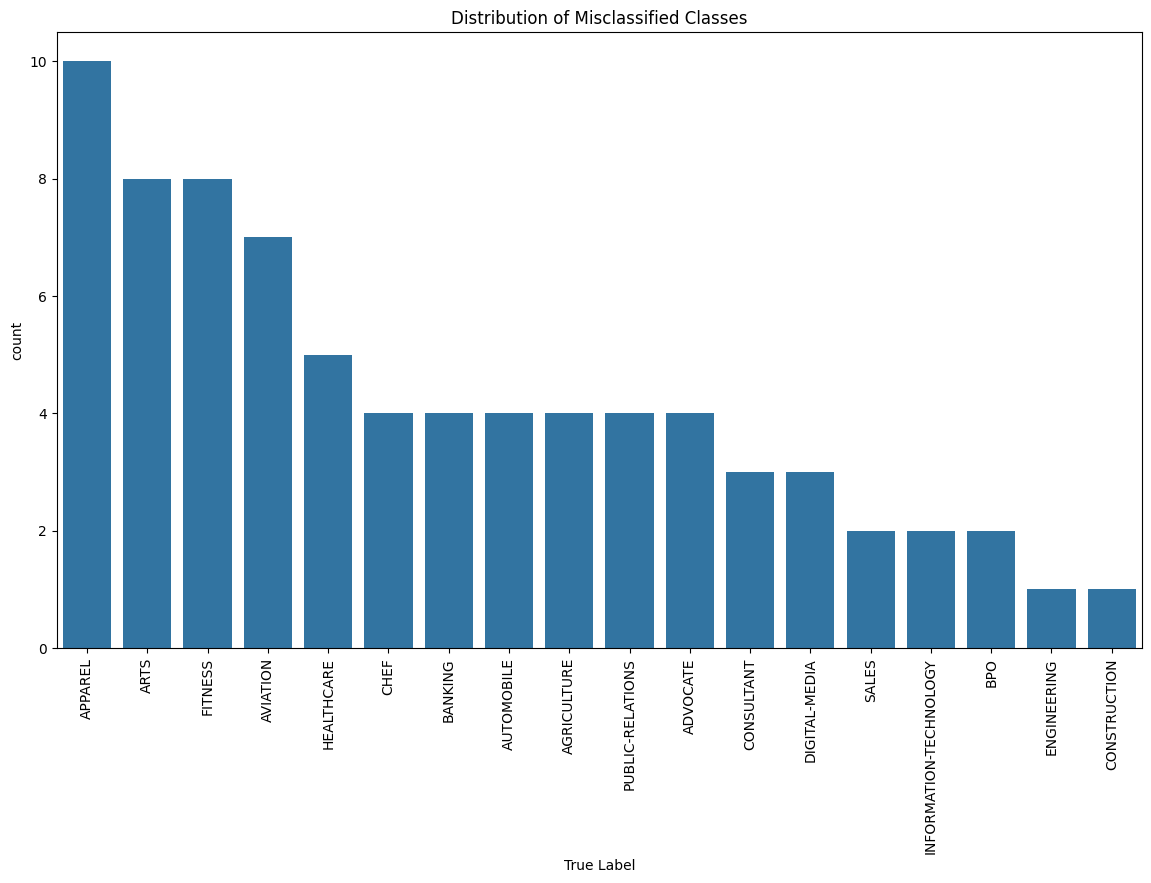

In [ ]:
plt.figure(figsize=(14, 8))
sns.countplot(x=misclassified_df["True Label"], order=misclassified_df["True Label"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Distribution of Misclassified Classes")
plt.show()

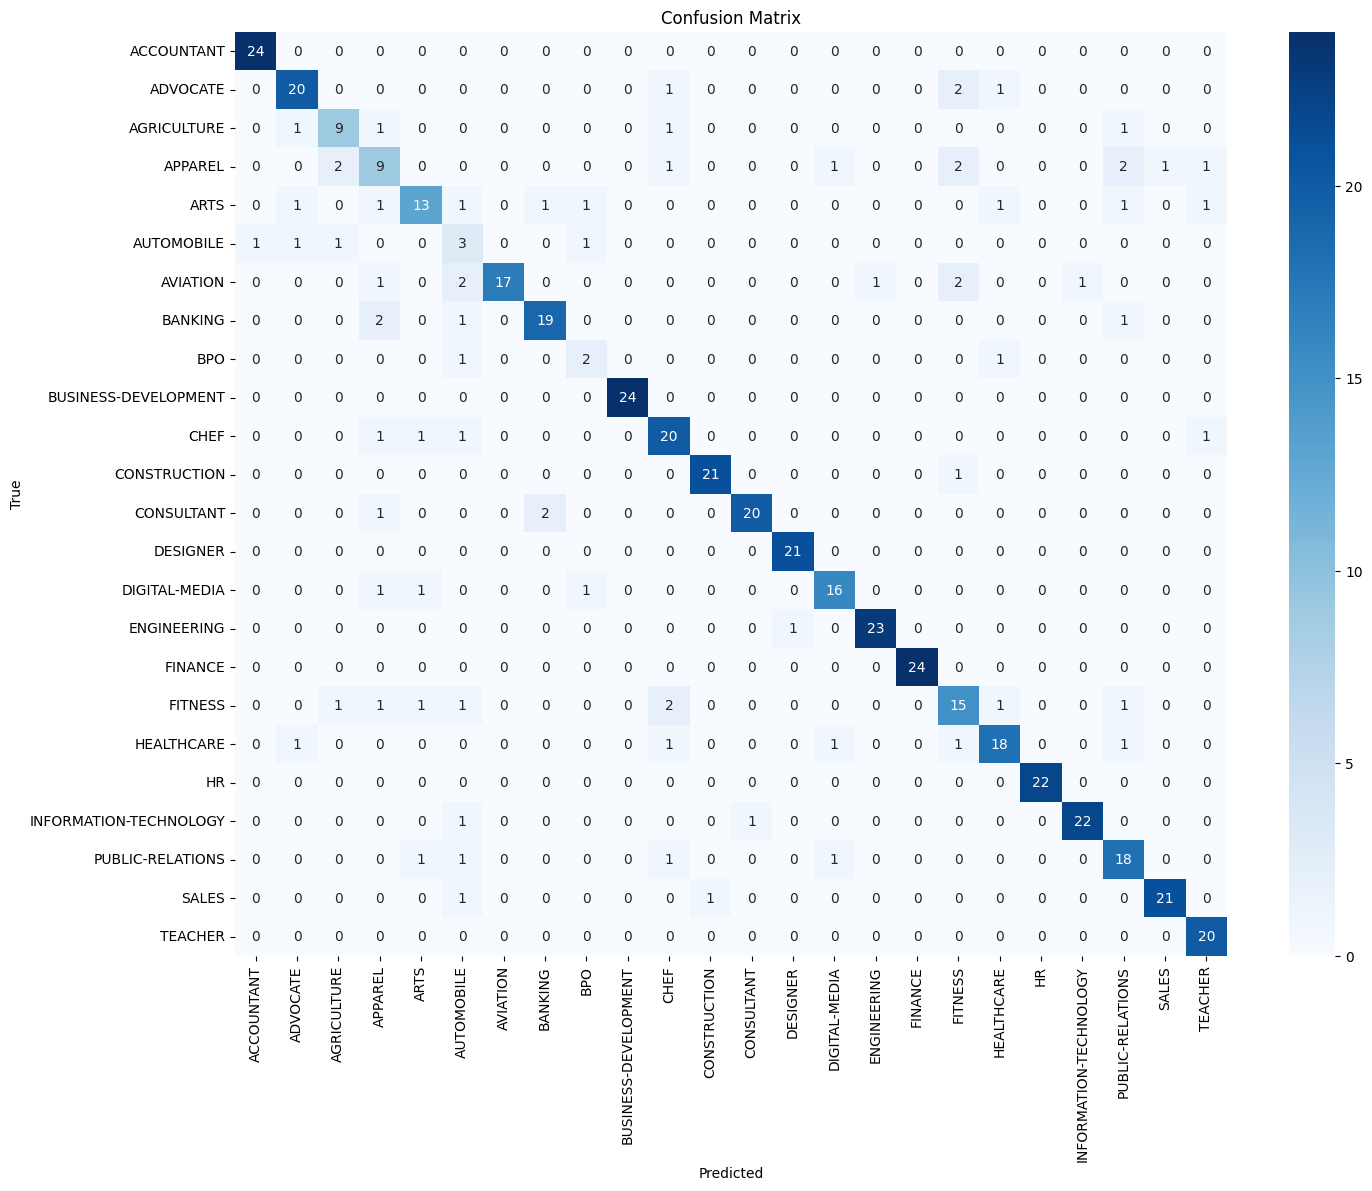

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred, labels=range(len(label_encoder.classes_)))
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Get the current learning rate
last_lr = tf.keras.backend.get_value(model.optimizer.lr)
print(f"Current learning rate: {last_lr}")

Current learning rate: 2.499999993688107e-07


Continue Training from Checkpoint

In [ ]:
from tensorflow.keras.models import load_model

# Path to the checkpoint
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/model_checkpoint.keras"

# Define a custom object scope to include TFBertModel
from keras.utils import custom_object_scope

with custom_object_scope({'TFBertModel': TFBertModel}):
    # Load the checkpoint
    model = load_model(checkpoint_path)

# (Optional) recompile if needed
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Checkpoint callback
checkpoint_cb = ModelCheckpoint(
    checkpoint_path,   # where to save
    save_best_only=True,      # only save if validation improves
    save_weights_only=False,  # or True if you only want weights
    monitor="val_loss",       # which metric to track
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    checkpoint_cb
]

# Resume training
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    batch_size=BATCH_SIZE,    # (if you know where you stopped before crash)
    epochs=20,          # (your original target)
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
269/269 [==============================] - 237s 704ms/step - loss: 0.8060 - accuracy: 0.7853 - val_loss: 0.6130 - val_accuracy: 0.8612
Epoch 2/20
269/269 [==============================] - 165s 615ms/step - loss: 0.7713 - accuracy: 0.7965 - val_loss: 0.6075 - val_accuracy: 0.8592
Epoch 3/20
269/269 [==============================] - 165s 615ms/step - loss: 0.7526 - accuracy: 0.8023 - val_loss: 0.5844 - val_accuracy: 0.8571
Epoch 4/20
269/269 [==============================] - 152s 565ms/step - loss: 0.7244 - accuracy: 0.8072 - val_loss: 0.6030 - val_accuracy: 0.8531
Epoch 5/20
269/269 [==============================] - 152s 564ms/step - loss: 0.6950 - accuracy: 0.8172 - val_loss: 0.5897 - val_accuracy: 0.8592
Epoch 6/20
269/269 [==============================] - 152s 564ms/step - loss: 0.6789 - accuracy: 0.8214 - val_loss: 0.6031 - val_accuracy: 0.8571
Epoch 7/20
269/269 [==============================] - 152s 564ms/step - loss: 0.6570 - accuracy: 0.8268 - val_loss: 0.5935 -

In [ ]:
# Plot Training vs Validation Loss
plt.figure(figsize=(12, 5))

# ---- Plot Loss ----
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# ---- Plot Accuracy ----
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()